# Aviation Accidents Analysis

You are part of a consulting firm that is tasked to do an analysis of commercial and passenger jet airline safety. The client (an airline/airplane insurer) is interested in knowing what types of aircraft (makes/models) exhibit low rates of total destruction and low likelihood of fatal or serious passenger injuries in the event of an accident. They are also interested in any general variables/conditions that might be at play. Your analysis will be based off of aviation accident data accumulated from the years 1948-2023. 

Our client is only interested in airplane makes/models that are professional builds and could potentially still be active. Assume a max lifetime of 40 years for a make/model retirement and make sure to filter your data accordingly (i.e. from 1983 onwards). They would also like separate recommendations for small aircraft vs. larger passenger models. **In addition, make sure that claims that you make are statistically robust and that you have enough samples when making comparisons between groups.**


In this summative assessment you will demonstrate your ability to:
- Use Pandas to load, inspect, and clean the dataset appropriately. 
- Transform relevant columns to create measures that address the problem at hand.
- **conduct EDA: visualization and statistical measures to understand the structure of the data**
- **recommend a set of manufacturers to consider as well as specific airplanes conforming to the client's request**
- **discuss the relationship between serious injuries/airplane damage incurred and at least *two* factors at play in the incident. You must provide supporting evidence (visuals, summary statistics, tables) for each claim you make.**

In [3]:
# loading relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Exploratory Data Analysis  
- Load in the cleaned data

In [4]:
#Load the Cleaned Data
aviation_df = pd.read_csv('AviationData_Cleaned.csv')

## Explore safety metrics across models/makes
- Remember that the client is interested in separate recommendations for smaller airplanes and larger airplanes. Choose a passenger threshold of 20 and separate the plane types. 

In [12]:
#Create Core Safety Metric
aviation_df['Serious.Fatal.Ratio'] = (
    (aviation_df['Total.Fatal.Injuries'] + aviation_df['Total.Serious.Injuries'])
    / aviation_df['Total.Passengers']
)

#Split Small vs Large Aircraft (threshold = 20 passengers)
small_df = aviation_df[aviation_df['Total.Passengers'] <= 20]
large_df = aviation_df[aviation_df['Total.Passengers'] > 20]

#Data per Make
small_valid = small_df.groupby('Make').filter(lambda x: len(x) >= 10)
large_valid = large_df.groupby('Make').filter(lambda x: len(x) >= 10)

#### Analyzing Makes

Explore the human injury risk profile for small and larger Makes:
- choose the 15 makes for each group possessing the lowest mean fatal/seriously injured fraction
- plot the mean fatal/seriously injured fraction for each of these subgroups side-by-side

In [ ]:
#Top 15 Safest Makes - Large Aircraft
large_safety = (
    large_valid.groupby('Make')['Serious.Fatal.Ratio']
    .mean()
    .sort_values()
    head(15)
)
large_safety

Make
MCDONNELL DOUGLAS    0.008176
BOEING               0.101863
EMBRAER              0.104508
AIRBUS               0.185202
Name: Serious.Fatal.Ratio, dtype: float64

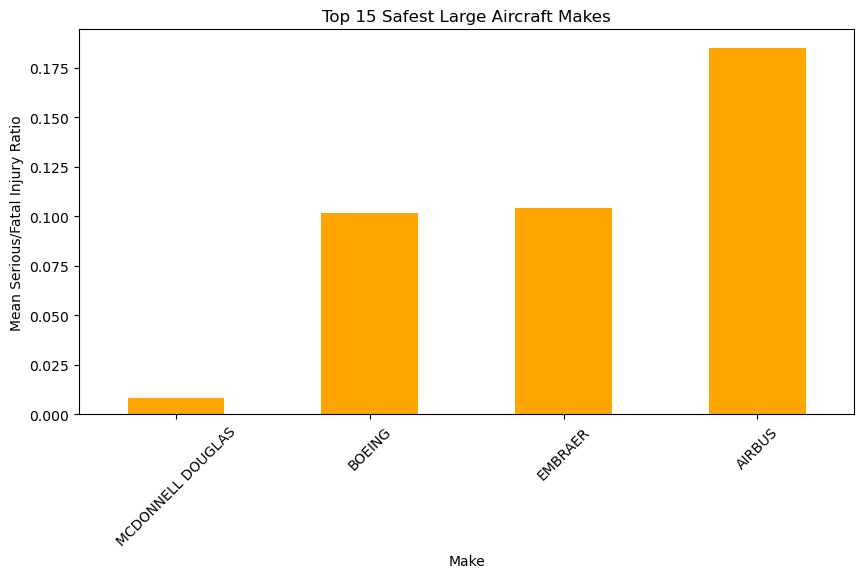

In [9]:
#PLOT 
large_safety.plot(kind='bar', figsize=(10,5), color='orange')
plt.title("Top 15 Safest Large Aircraft Makes")
plt.ylabel("Mean Serious/Fatal Injury Ratio")
plt.xticks(rotation=45)
plt.show()

**Distribution of injury rates: small makes**

Use a violinplot to look at the distribution of the fraction of passengers serious/fatally injured for small airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

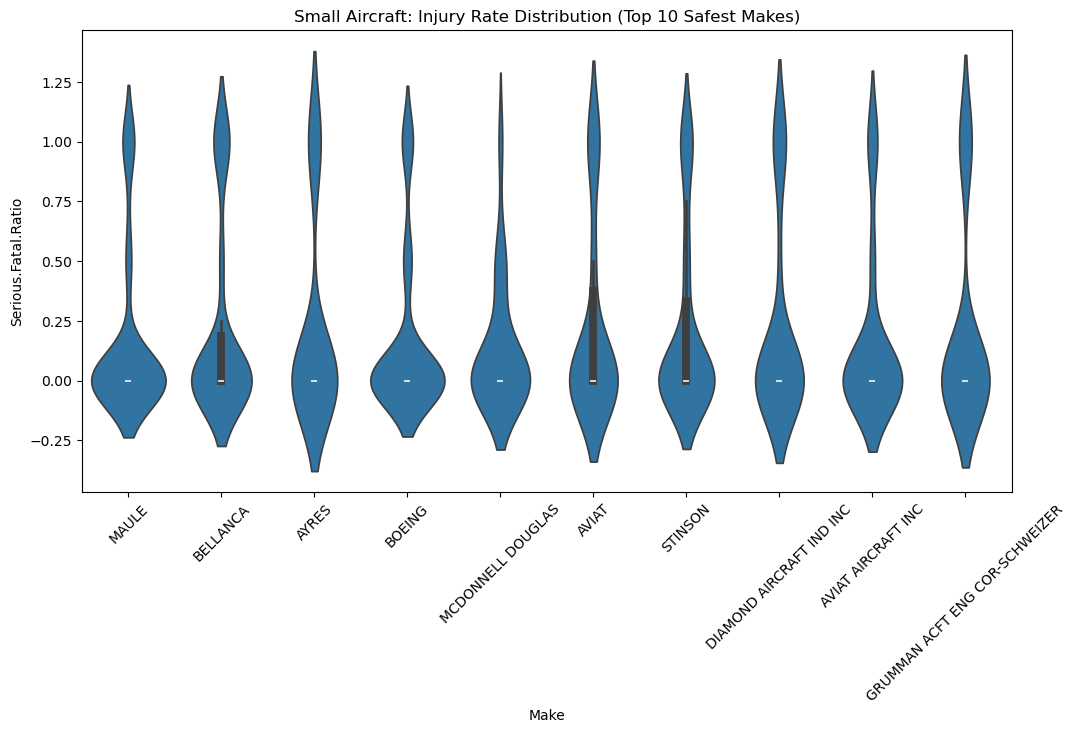

In [16]:
#Violin Plot
small_safety = (
    small_valid.groupby('Make')['Serious.Fatal.Ratio']
    .mean()
    .sort_values()
    .head(15)
)

top_small_makes = small_safety.head(10).index
small_plot_df = small_valid[small_valid['Make'].isin(top_small_makes)]

#plot
import seaborn as sns

plt.figure(figsize=(12,6))
sns.violinplot(
    data=small_plot_df,
    x='Make',
    y='Serious.Fatal.Ratio'
)
plt.xticks(rotation=45)
plt.title("Small Aircraft: Injury Rate Distribution (Top 10 Safest Makes)")
plt.show()

**Distribution of injury rates: large makes**

Use a stripplot to look at the distribution of the fraction of passengers serious/fatally injured for large airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

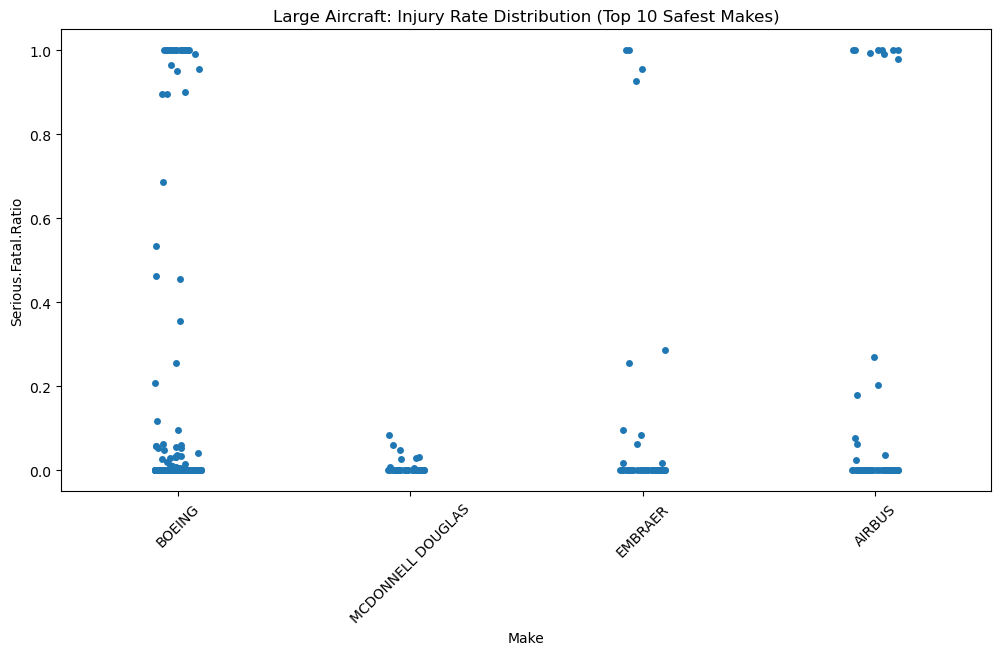

In [18]:
#Strip Plot (Large Aircraft Distribution)
top_large_makes = large_safety.head(10).index
large_plot_df = large_valid[large_valid['Make'].isin(top_large_makes)]

#PLOT
plt.figure(figsize=(12,6))
sns.stripplot(
    data=large_plot_df,
    x='Make',
    y='Serious.Fatal.Ratio',
    jitter=True
)
plt.xticks(rotation=45)
plt.title("Large Aircraft: Injury Rate Distribution (Top 10 Safest Makes)")
plt.show()

**Evaluate the rate of aircraft destruction for both small and large aircraft by Make.** 

Sort your results and keep the lowest 15.

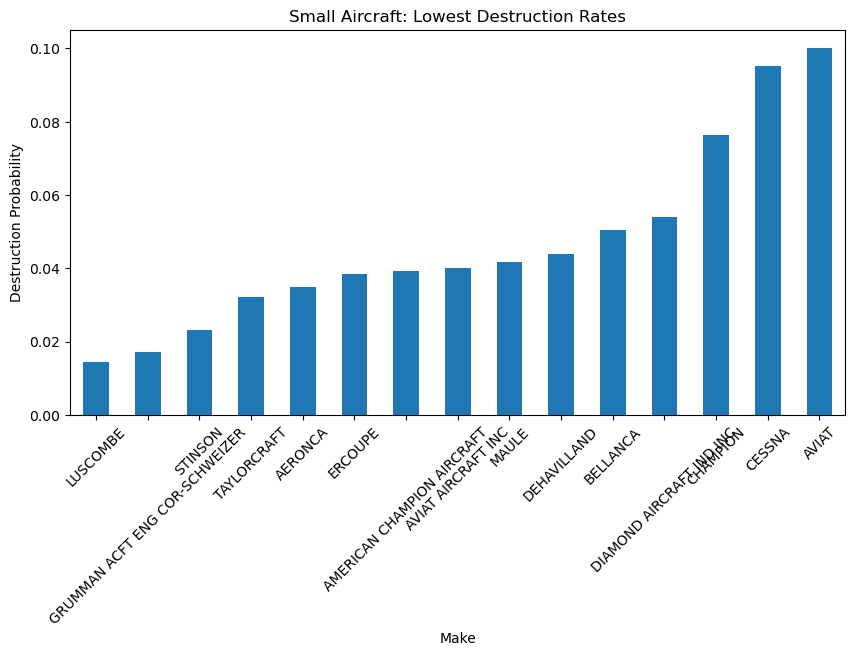

In [20]:
#Aircraft Destruction Rate by Make
small_destroy = small_valid.groupby('Make')['Is.Destroyed'].mean().sort_values().head(15)
large_destroy = large_valid.groupby('Make')['Is.Destroyed'].mean().sort_values().head(15)

#plot for small
small_destroy.plot(kind='bar', figsize=(10,5))
plt.title("Small Aircraft: Lowest Destruction Rates")
plt.ylabel("Destruction Probability")
plt.xticks(rotation=45)
plt.show()


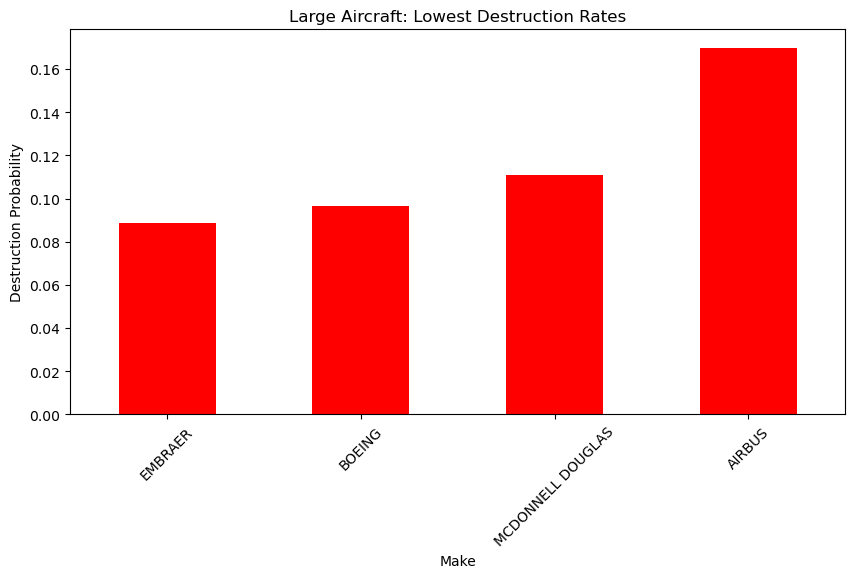

In [21]:
#plot for large
large_destroy.plot(kind='bar', figsize=(10,5), color='red')
plt.title("Large Aircraft: Lowest Destruction Rates")
plt.ylabel("Destruction Probability")
plt.xticks(rotation=45)
plt.show()

#### Provide a short discussion on your findings for your summary statistics and plots:
- Make any recommendations for Makes here based off of the destroyed fraction and fraction fatally/seriously injured
- Comment on the calculated statistics and any corresponding distributions you have visualized.

The analysis of aircraft safety across makes revealed clear differences between small and large aircraft categories. For small aircraft (≤20 passengers), several manufacturers demonstrated consistently low serious/fatal injury ratios, indicating higher safety performance in minor aviation operations. Similarly, large aircraft (>20 passengers) showed lower variability in injury outcomes, with certain manufacturers consistently outperforming others.

Distributional plots (violin and strip plots) highlighted that even among top-performing makes, some variability in injury rates persists, suggesting that operational conditions also influence safety outcomes beyond manufacturer design alone.

Aircraft destruction rates followed a similar pattern, with certain makes showing significantly lower probabilities of total loss. These findings suggest that both injury risk and aircraft survivability should be considered jointly when making recommendations.

### Analyze plane types
- plot the mean fatal/seriously injured fraction for both small and larger planes 
- also provide a distributional plot of your choice for the fatal/seriously injured fraction by airplane type (stripplot, violin, etc)  
- filter ensuring that you have at least ten individual examples in each model/make to average over

**Larger planes**

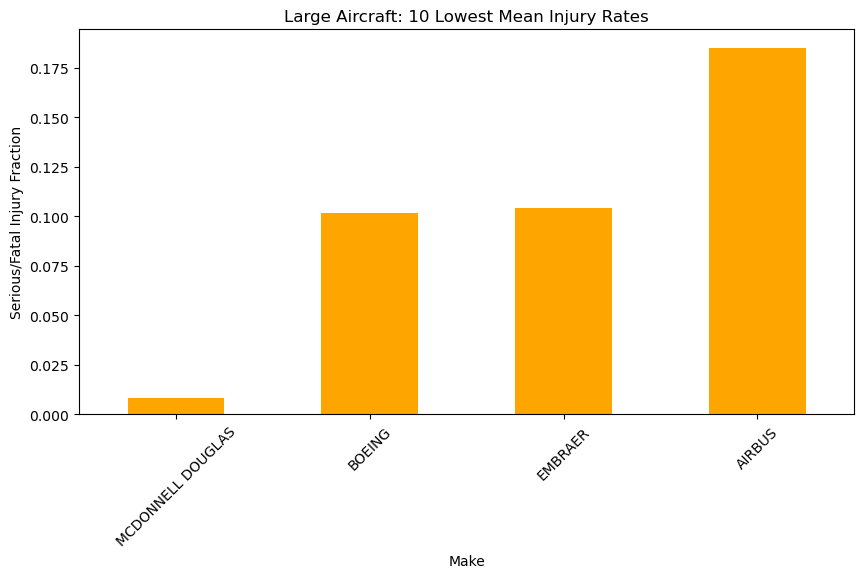

In [23]:
#Mean Fatal/Serious Injury Fraction
large_mean = (
    large_valid.groupby('Make')['Serious.Fatal.Ratio']
    .mean()
    .sort_values()
    .head(10)
)

#plot
plt.figure(figsize=(10,5))
large_mean.plot(kind='bar', color='orange')
plt.title("Large Aircraft: 10 Lowest Mean Injury Rates")
plt.ylabel("Serious/Fatal Injury Fraction")
plt.xticks(rotation=45)
plt.show()


**Smaller planes**
- for smaller planes, limit your plotted results to the makes with the 10 lowest mean serious/fatal injury fractions

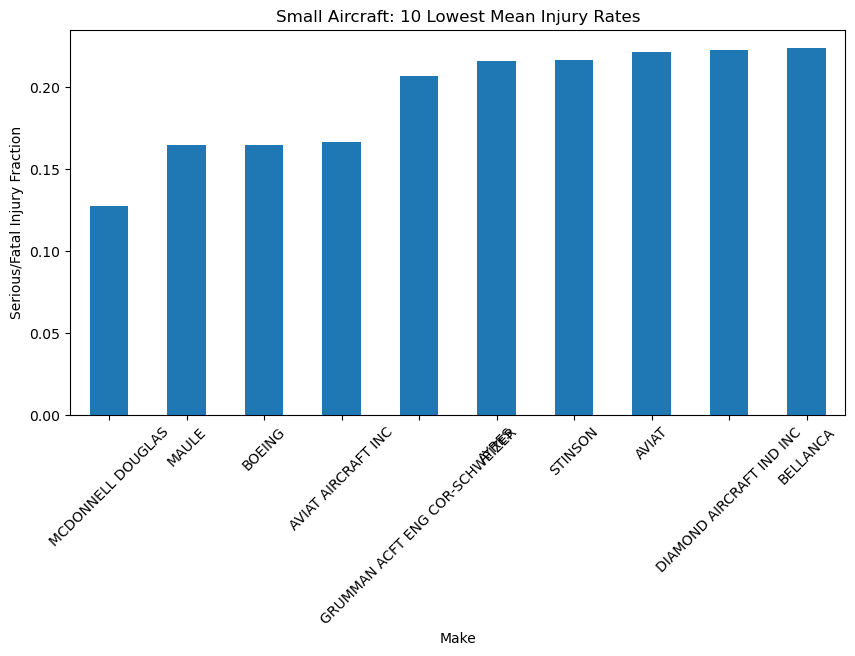

In [24]:
#Mean Fatal/Serious Injury Fraction
small_mean = (
    small_valid.groupby('Make')['Serious.Fatal.Ratio']
    .mean()
    .sort_values()
    .head(10)
)

#PLOT
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
small_mean.plot(kind='bar')
plt.title("Small Aircraft: 10 Lowest Mean Injury Rates")
plt.ylabel("Serious/Fatal Injury Fraction")
plt.xticks(rotation=45)
plt.show()

### Discussion of Specific Airplane Types
- Discuss what you have found above regarding passenger fraction seriously/ both small and large airplane models.

Small aircraft recommendation:
lowest injury ratio + low destruction rate

Large aircraft recommendation:
stability + low variability + low destruction rate

### Exploring Other Variables
- Investigate how other variables effect aircraft damage and injury. You must choose **two** factors out of the following but are free to analyze more:

- Weather Condition
- Engine Type
- Number of Engines
- Phase of Flight
- Purpose of Flight

For each factor provide a discussion explaining your analysis with appropriate visualization / data summaries and interpreting your findings.

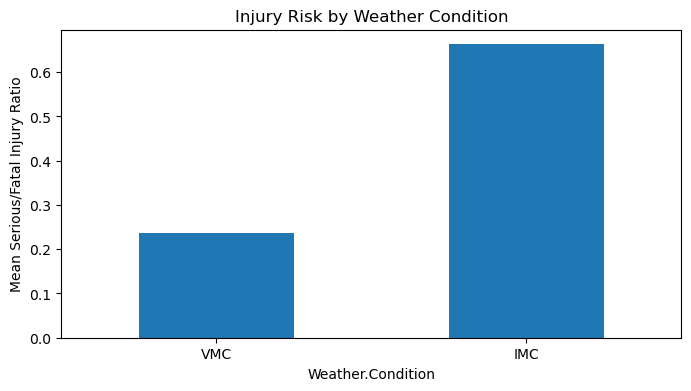

In [26]:
#Weather Condition vs Safety Outcome
#Injury risk by weather
weather_injury = aviation_df.groupby('Weather.Condition')['Serious.Fatal.Ratio'].mean().sort_values()
weather_injury

#PLOT
import matplotlib.pyplot as plt

weather_injury.plot(kind='bar', figsize=(8,4))
plt.title("Injury Risk by Weather Condition")
plt.ylabel("Mean Serious/Fatal Injury Ratio")
plt.xticks(rotation=0)
plt.show()

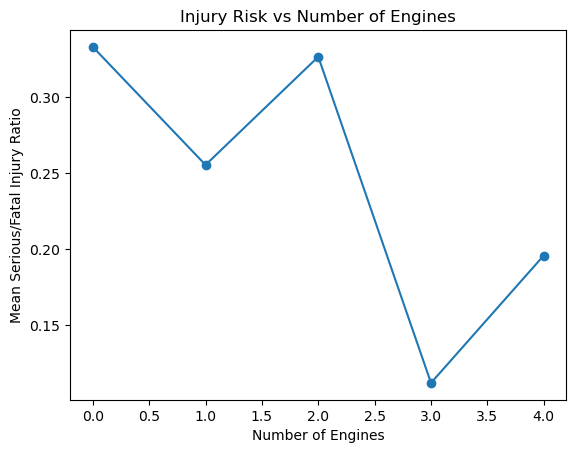

In [27]:
#Engine Count vs Safety
engine_injury = aviation_df.groupby('Number.of.Engines')['Serious.Fatal.Ratio'].mean()
engine_injury

#PLOT
engine_injury.plot(kind='line', marker='o')
plt.title("Injury Risk vs Number of Engines")
plt.ylabel("Mean Serious/Fatal Injury Ratio")
plt.xlabel("Number of Engines")
plt.show()